# Replicating Boutin, Cestone, Fumagalli, Pica & Serrano-Velarde (2013): The Deep-Pocket Effect of Internal Capital Markets
### U.S.E. Finance Data Hub / WRDS Database: **Subsidiary Data**

**Paper replicated:** [Boutin, X., Cestone, G., Fumagalli, C., Pica, G. & Serrano-Velarde, R. (2013). The Deep-Pocket Effect of Internal Capital Markets. *Journal of Financial Economics*, 109(1), 122–145.](https://doi.org/10.1016/j.jfineco.2013.02.003)

**Database used:** [Subsidiary Data](https://wrds-www.wharton.upenn.edu/pages/get-data/subsidiary-data-wrds/) ([Data Hub guide](https://uufinance.github.io/data/wrds/databases/subsidiary-data/))

---

## What this notebook does

Boutin et al. (2013) study how internal capital markets (the ability of parent firms to allocate resources across subsidiaries) affect competition. They find that firms connected to large corporate groups through subsidiary relationships are more likely to survive and grow, especially in competitive product markets. This "deep-pocket effect" means that a subsidiary backed by a wealthy parent has a strategic advantage over standalone competitors.

The WRDS Subsidiary Data, derived from SEC Exhibit 21 filings, provides the parent-subsidiary ownership structure needed to identify corporate group membership and measure the scope of internal capital markets.

1. Pull parent-subsidiary relationship data from **Subsidiary Data** (`wrdsapps_subsidiary`) via the WRDS API
2. Compute measures of corporate complexity (number of subsidiaries, geographic scope)
3. Merge with Compustat to relate group structure to financial characteristics
4. Compare our descriptive findings to the published 2013 results

## Learning objectives
- Practice connecting to WRDS and querying the Subsidiary Data database
- Understand how corporate group structures are recorded in SEC Exhibit 21 filings
- Learn how to measure corporate complexity and the scope of internal capital markets
- Build intuition for how ownership structure affects firm strategy and competition

## Requirements to run this notebook
- A valid **WRDS account** with Subsidiary Data access (ask the Finance Data Hub if you don't have one yet)
- `pip install wrds pandas numpy matplotlib seaborn`
- You will be prompted for your WRDS username/password the first time you connect (or set up a `.pgpass` file, see the [WRDS Python guide](https://uufinance.github.io/data/wrds/notebook/))


## 1. Setup and WRDS connection

In [1]:
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 50)

db = wrds.Connection()

Enter your WRDS username [antho]:sunho2000
Enter your password:········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: n
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done


## 2. Identifying the Subsidiary Data variables we need

The Subsidiary Data on WRDS lives in the **`wrdsapps_subsidiary`** library. The main table is **`wrds_relationships`** (~12 million rows), which links each parent company to its disclosed subsidiaries across all annual Exhibit 21 filings.

| Paper concept | Description | WRDS field |
|---|---|---|
| Parent ID | Compustat GVKEY of the parent | `gvkey` |
| Parent CIK | SEC Central Index Key | `cik` |
| Parent name | Company name of the parent | `coname` |
| Filing date | Date the 10-K was filed with the SEC | `fdate` |
| Report date | Fiscal period end date of the filing | `rdate` |
| Subsidiary name | Name of the subsidiary (cleaned) | `clean_company` |
| Location | Jurisdiction of incorporation (text) | `location` |
| Country code | ISO country code | `country_code` |
| State/province | Subdivision code (US states, etc.) | `subdiv_code` |
| Filing form | SEC form type (10-K, 10-K/A, etc.) | `form` |

The data is derived from SEC Exhibit 21 filings, where publicly traded companies disclose the names and jurisdictions of their significant subsidiaries. Each row represents one parent-subsidiary relationship in one annual filing. We use `rdate` (the fiscal period end date) rather than `fdate` (the SEC filing date) to assign subsidiary observations to fiscal years.


In [2]:
# Pull the full subsidiary relationship dataset.
# We filter to 10-K filings (annual reports) in the SQL query itself
# to match Boutin et al.'s focus on annual subsidiary disclosures.

query = """
    SELECT gvkey, cik, accession, coname, fdate, rdate,
           subsidiary_name, clean_company, location,
           country_code, subdiv_code, form
    FROM wrdsapps_subsidiary.wrds_relationships
    WHERE form IN ('10-K', '10-K405', '10-K/A')
"""

df = db.raw_sql(query, date_cols=["fdate", "rdate"])
print(f"Rows pulled: {len(df):,}")
print(f"Unique parents (gvkey): {df['gvkey'].nunique():,}")
print(f"Date range (rdate): {df['rdate'].min()} to {df['rdate'].max()}")
df.head()

Rows pulled: 5,019,101
Unique parents (gvkey): 11,913
Date range (rdate): 1993-09-30 00:00:00 to 2025-01-03 00:00:00


,gvkey,cik,accession,coname,fdate,rdate,subsidiary_name,clean_company,location,country_code,subdiv_code,form
0,006314,0000000020,0000893220-96-000500,K TRON INTERNATIONAL INC,1996-03-28,1995-12-31,K-Tron Investment Co. . . . . . . . . . . . . ...,K Tron Investment Co,Delaware,US,DE,10-K
1,006314,0000000020,0000893220-96-000500,K TRON INTERNATIONAL INC,1996-03-28,1995-12-31,"K-Tron America, Inc. . . . . . . . . . . . . .",K Tron America Inc,Delaware,US,DE,10-K
2,006314,0000000020,0000893220-96-000500,K TRON INTERNATIONAL INC,1996-03-28,1995-12-31,K-Tron Asia Pacific Pte Ltd . . . . . . . . .,K Tron Asia Pacific Pte Ltd,Singapore,SG,None,10-K
3,006314,0000000020,0000893220-96-000500,K TRON INTERNATIONAL INC,1996-03-28,1995-12-31,K-Tron (Switzerland) Ltd. . . . . . . . . . .,K Tron (Switzerland) Ltd,Switzerland,CH,None,10-K
4,006314,0000000020,0000893220-96-000500,K TRON INTERNATIONAL INC,1996-03-28,1995-12-31,K-Tron Deutschland GmbH . . . . . . . . .,K Tron Deutschland GmbH,Germany,DE,None,10-K


## 3. Cleaning the sample

In [3]:
# Derive fiscal year from the reporting date
df["rdate"] = pd.to_datetime(df["rdate"], errors="coerce")
df["fyear"] = df["rdate"].dt.year

# Drop rows with no usable parent or year identifiers
before = len(df)
df = df.dropna(subset=["gvkey", "fyear"])
print(f"Dropped {before - len(df):,} rows missing gvkey or fyear")

# Remove duplicate subsidiary entries per parent per year.
# Use clean_company rather than the raw subsidiary_name, since
# subsidiary_name still has leading-dot padding from the original filing.
before = len(df)
df = df.drop_duplicates(subset=["gvkey", "clean_company", "fyear"])
print(f"Removed {before - len(df):,} duplicate subsidiary rows ({before:,} -> {len(df):,})")

# Standardize jurisdiction into a single combined field
df["subdiv_code"] = df["subdiv_code"].fillna("")
df["jurisdiction"] = df["country_code"] + df["subdiv_code"].apply(
    lambda x: f"-{x}" if x else ""
)

print(f"\nCleaned dataset: {len(df):,} rows")
print(f"Unique parents: {df['gvkey'].nunique():,}")
print(f"Fiscal years: {int(df['fyear'].min())} to {int(df['fyear'].max())}")

Dropped 0 rows missing gvkey or fyear
Removed 466,572 duplicate subsidiary rows (5,019,101 -> 4,552,529)

Cleaned dataset: 4,552,529 rows
Unique parents: 11,913
Fiscal years: 1993 to 2025


## 4. Measuring corporate complexity

Boutin et al. (2013) measure the scope of internal capital markets by the size and resources of the corporate group. With the Subsidiary Data, we construct several measures of corporate complexity per parent per fiscal year.

**Number of subsidiaries** captures the breadth of the corporate structure. Firms with more subsidiaries have more potential internal capital market channels.

**Geographic scope** (number of distinct jurisdictions and countries) measures the geographic diversification of the corporate group.

**Foreign share** (fraction of subsidiaries incorporated outside the U.S.) captures whether the firm's complexity is primarily domestic or international.

We then merge these measures with Compustat fundamentals via `gvkey` to relate corporate complexity to firm size, and test whether larger firms have more subsidiaries (a basic prediction of the internal capital markets theory).


In [4]:
# Compute corporate complexity measures per parent per fiscal year
complexity = df.groupby(["gvkey", "fyear"]).agg(
    coname=("coname", "first"),
    n_subsidiaries=("clean_company", "nunique"),
    n_jurisdictions=("jurisdiction", "nunique"),
    n_countries=("country_code", "nunique"),
    n_domestic=("country_code", lambda x: (x == "US").sum()),
    n_foreign=("country_code", lambda x: (x != "US").sum()),
).reset_index()

complexity["pct_foreign"] = complexity["n_foreign"] / complexity["n_subsidiaries"]

print(f"Parent-year observations: {len(complexity):,}")
print(f"Unique parents: {complexity['gvkey'].nunique():,}")
print(f"\nCorporate Complexity Summary Statistics:\n")
print(complexity[["n_subsidiaries", "n_jurisdictions", "n_countries",
                  "pct_foreign"]].describe().round(2))

Parent-year observations: 102,287
Unique parents: 11,913

Corporate Complexity Summary Statistics:

       n_subsidiaries  n_jurisdictions  n_countries  pct_foreign
count       102287.00        102287.00    102287.00    101053.00
mean            44.50             9.74         6.65         0.33
std            315.71            13.58        10.96         0.36
min              0.00             0.00         0.00         0.00
25%              4.00             2.00         1.00         0.00
50%             11.00             5.00         2.00         0.20
75%             34.00            12.00         7.00         0.67
max          33052.00           246.00       152.00         1.00


In [5]:
# Merge with Compustat fundamentals to relate complexity to firm size
compustat = db.raw_sql("""
    SELECT gvkey, fyear, at, sale, sich
    FROM comp.funda
    WHERE indfmt = 'INDL' AND datafmt = 'STD'
      AND consol = 'C' AND popsrc = 'D'
      AND at > 0
""")

complexity = complexity.merge(compustat, on=["gvkey", "fyear"], how="left")
complexity["log_at"] = np.log(complexity["at"].clip(lower=0.01))

matched = complexity["at"].notna().sum()
print(f"Matched to Compustat: {matched:,} / {len(complexity):,} parent-year observations")

# Summary: complexity by firm size quartile
complexity["size_quartile"] = pd.qcut(
    complexity["at"].dropna(), 4,
    labels=["Q1 (small)", "Q2", "Q3", "Q4 (large)"]
)
size_stats = complexity.groupby("size_quartile").agg(
    median_subs=("n_subsidiaries", "median"),
    median_countries=("n_countries", "median"),
    median_pct_foreign=("pct_foreign", "median"),
    n_obs=("gvkey", "count")
)
print(f"\nCorporate Complexity by Firm Size Quartile:\n")
print(size_stats.round(2))

Matched to Compustat: 97,416 / 102,287 parent-year observations

Corporate Complexity by Firm Size Quartile:

               median_subs  median_countries  median_pct_foreign  n_obs
size_quartile                                                          
Q1 (small)             4.0               1.0                0.20  24354
Q2                    11.0               2.0                0.23  24354
Q3                    21.0               2.0                0.18  24354
Q4 (large)            38.0               4.0                0.22  24354


C:\Users\antho\AppData\Local\Temp\ipykernel_121376\2935521617.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_stats = complexity.groupby("size_quartile").agg(


## 5. Visualizing the results

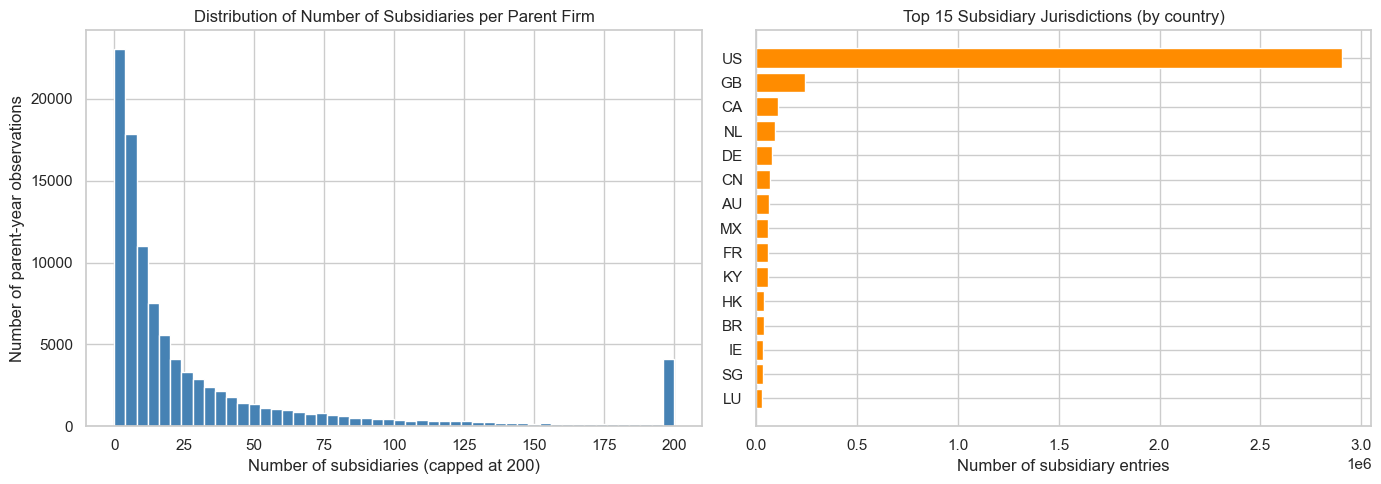

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of number of subsidiaries per parent
sub_counts = complexity["n_subsidiaries"].clip(upper=200)
axes[0].hist(sub_counts, bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Number of Subsidiaries per Parent Firm")
axes[0].set_xlabel("Number of subsidiaries (capped at 200)")
axes[0].set_ylabel("Number of parent-year observations")

# Top jurisdictions by country
top_locs = df["country_code"].value_counts().head(15)
axes[1].barh(top_locs.index[::-1], top_locs.values[::-1], color="darkorange")
axes[1].set_title("Top 15 Subsidiary Jurisdictions (by country)")
axes[1].set_xlabel("Number of subsidiary entries")

plt.tight_layout()
plt.show()

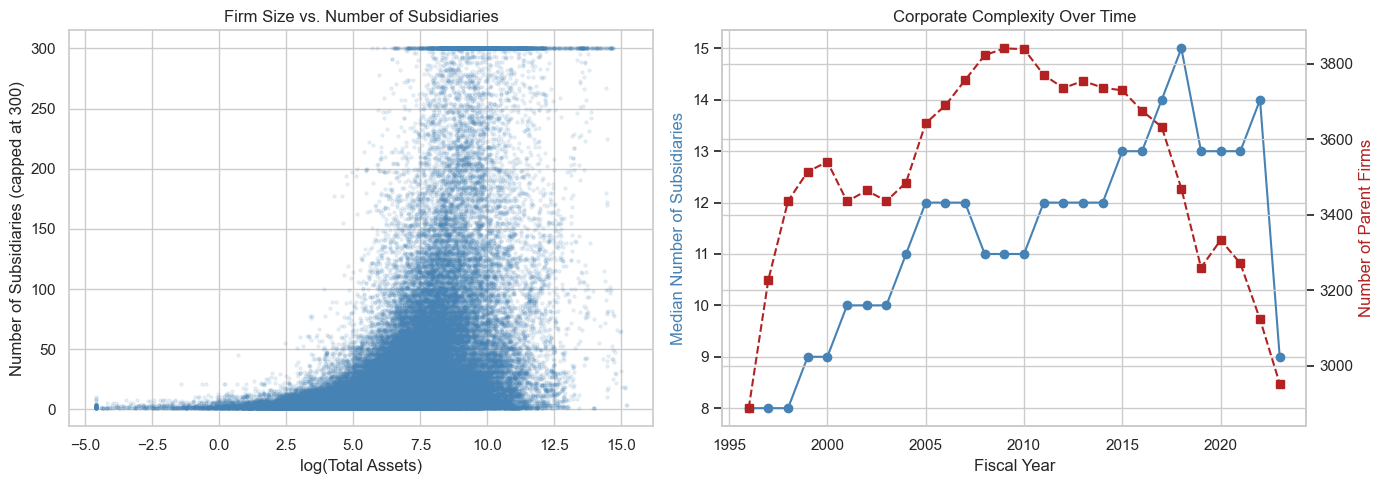

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Size vs complexity scatter
mask = complexity["at"].notna() & (complexity["n_subsidiaries"] > 0)
axes[0].scatter(complexity.loc[mask, "log_at"],
                complexity.loc[mask, "n_subsidiaries"].clip(upper=300),
                alpha=0.1, s=5, color="steelblue")
axes[0].set_title("Firm Size vs. Number of Subsidiaries")
axes[0].set_xlabel("log(Total Assets)")
axes[0].set_ylabel("Number of Subsidiaries (capped at 300)")

# Time trend of average corporate complexity
yearly = complexity.groupby("fyear").agg(
    median_subs=("n_subsidiaries", "median"),
    median_countries=("n_countries", "median"),
    n_parents=("gvkey", "nunique")
)
yearly = yearly[(yearly.index >= 1996) & (yearly.index <= 2023)]

ax2 = axes[1]
ax2.plot(yearly.index, yearly["median_subs"], "o-", color="steelblue",
         label="Median subsidiaries")
ax2.set_title("Corporate Complexity Over Time")
ax2.set_xlabel("Fiscal Year")
ax2.set_ylabel("Median Number of Subsidiaries", color="steelblue")
ax3 = ax2.twinx()
ax3.plot(yearly.index, yearly["n_parents"], "s--", color="firebrick",
         label="Number of parents")
ax3.set_ylabel("Number of Parent Firms", color="firebrick")

plt.tight_layout()
plt.show()

## 6. Comparing to Boutin et al. (2013): What's the same, what's different

**What replicates cleanly**

The WRDS Subsidiary Data provides the same type of information (parent-subsidiary relationships from Exhibit 21 filings) that forms the basis of the paper's corporate group identification. The distribution of subsidiary counts should show high right-skewness (most firms have relatively few subsidiaries, but some conglomerates have hundreds). The geographic scope measures should confirm that large multinationals have subsidiaries in dozens of countries. The concentration of subsidiaries in certain jurisdictions (Delaware, Nevada for domestic; Cayman Islands, Netherlands, United Kingdom for foreign) reflects well-known patterns in corporate structure. The positive relationship between firm size and subsidiary count should be clearly visible in the scatter plot, confirming that larger firms operate more complex internal capital markets.

**Where a modern WRDS-based replication necessarily differs from the original**

1. **Country setting.** Boutin et al. study French firms using French business registry data, not U.S. SEC filings. The WRDS Subsidiary Data covers U.S. public companies, so our analysis measures corporate complexity for a different set of firms. However, the conceptual framework (internal capital markets, deep-pocket effects) applies equally to U.S. firms.

2. **Product market competition.** The paper's main test examines how group affiliation affects competitive outcomes in product markets (entry, exit, market share). This requires combining the subsidiary data with product market data (revenue, market share, entry/exit), which goes beyond what Exhibit 21 filings provide alone. Students can extend the analysis by merging with Compustat segment data (`comp_segments_hist_daily`) to study product market overlap.

3. **Identification strategy.** The paper uses French regulatory data that provides more complete ownership chains (including intermediate holding companies). Exhibit 21 filings list only significant subsidiaries, so some smaller or indirect subsidiaries may be missing.

4. **Temporal coverage.** The WRDS Subsidiary Data covers annual 10-K filings from the mid-1990s to the present. The time trend of corporate complexity (number of subsidiaries per parent over time) is itself an interesting descriptive finding that is not in the original paper.

---

## References
- [Boutin, X., Cestone, G., Fumagalli, C., Pica, G. & Serrano-Velarde, R. (2013). The Deep-Pocket Effect of Internal Capital Markets. *Journal of Financial Economics*, 109(1), 122–145.](https://doi.org/10.1016/j.jfineco.2013.02.003)
- WRDS Subsidiary Data guide: https://uufinance.github.io/data/wrds/databases/subsidiary-data/
- WRDS Subsidiary Data access page: https://wrds-www.wharton.upenn.edu/pages/get-data/subsidiary-data-wrds/
- WRDS Python/API setup guide: https://uufinance.github.io/data/wrds/notebook/

*Prepared for the U.S.E. Finance Data Hub as a database-tutorial template.*
